<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2460 acc 0.497 | val loss 0.9492 acc 0.615 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7921 acc 0.652 | val loss 0.6421 acc 0.722 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.6562 acc 0.725 | val loss 0.7027 acc 0.693


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5042 acc 0.761 | val loss 0.4457 acc 0.800 *


...

[EfficientNet-B0] Epoch  25/100 | LR: 1.00e-05 | train loss 0.1525 acc 0.924 | val loss 0.3715 acc 0.863


[EfficientNet-B0] Epoch  26/100 | LR: 1.00e-05 | train loss 0.1284 acc 0.937 | val loss 0.3770 acc 0.871


[EfficientNet-B0] Epoch  27/100 | LR: 1.00e-05 | train loss 0.1241 acc 0.936 | val loss 0.3937 acc 0.873


[EfficientNet-B0] Epoch  28/100 | LR: 1.00e-05 | train loss 0.1438 acc 0.928 | val loss 0.3650 acc 0.866


[EfficientNet-B0] Epoch  29/100 | LR: 1.00e-05 | train loss 0.1073 acc 0.941 | val loss 0.3909 acc 0.861

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 29.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3368)


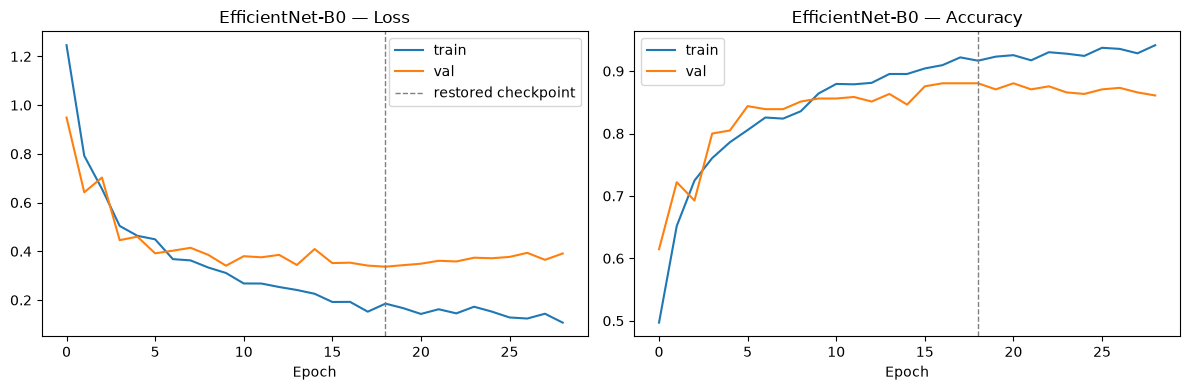

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.788


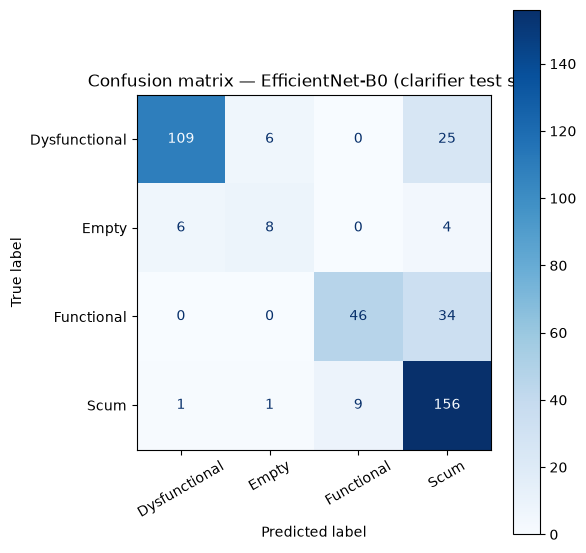

               precision    recall  f1-score   support

Dysfunctional      0.940     0.779     0.852       140
        Empty      0.533     0.444     0.485        18
   Functional      0.836     0.575     0.681        80
         Scum      0.712     0.934     0.808       167

     accuracy                          0.788       405
    macro avg      0.755     0.683     0.707       405
 weighted avg      0.807     0.788     0.784       405



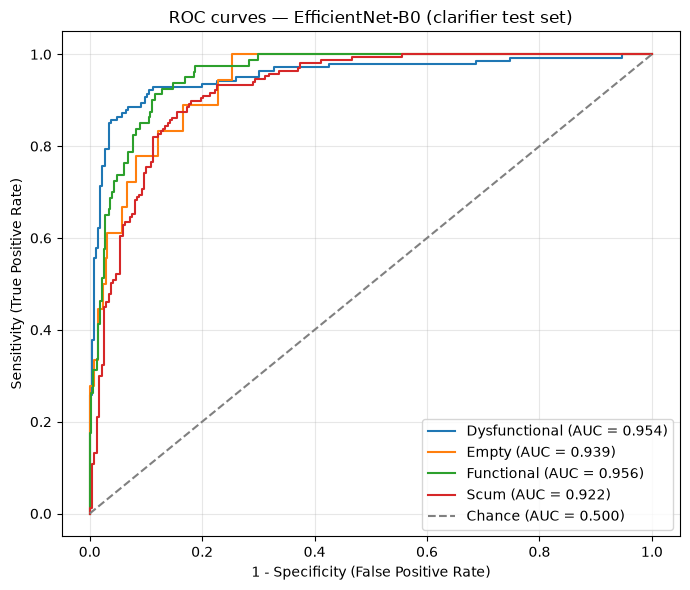

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.954
  Empty          : 0.939
  Functional     : 0.956
  Scum           : 0.922

Mean AUC (over 4/4 classes with test examples): 0.943


(np.float64(0.7876543209876543),
 {'Dysfunctional': 0.9537735849056603,
  'Empty': 0.9391329313809934,
  'Functional': 0.9561538461538461,
  'Scum': 0.9222814874452775})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
